# Apple Inc. - Workforce Analysis Report
## Comprehensive Statistical Analysis
---

In [37]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
import os
warnings.filterwarnings('ignore')

# Create output directory for plots
output_dir = 'output/company_overview'
os.makedirs(output_dir, exist_ok=True)
print(f"Output directory created: {output_dir}")

# Set McKinsey-style plotting parameters
plt.style.use('seaborn-v0_8-whitegrid')
MCKINSEY_BLUE = '#0077B6'
MCKINSEY_GRAY = '#4A4A4A'
MCKINSEY_LIGHT_BLUE = '#00B4D8'
MCKINSEY_PALETTE = ['#0077B6', '#00B4D8', '#90E0EF', '#CAF0F8', '#4A4A4A']

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'Helvetica']
plt.rcParams['font.size'] = 11
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10
plt.rcParams['legend.fontsize'] = 10
plt.rcParams['axes.edgecolor'] = '#CCCCCC'
plt.rcParams['axes.linewidth'] = 0.8
plt.rcParams['grid.alpha'] = 0.3

print("Libraries loaded successfully")

Output directory created: output/company_overview
Libraries loaded successfully


In [38]:
# Load the company data
df = pd.read_parquet('data/AAPL.parquet')
print(f"Dataset loaded: {df.shape[0]:,} employees, {df.shape[1]} columns")
print(f"\nColumn names:")
print(df.columns.tolist())

Dataset loaded: 287,161 employees, 25 columns

Column names:
['user_id', 'position_id', 'region', 'company_raw', 'country', 'state', 'location_raw', 'metro_area', 'msa', 'city', 'remote_suitability', 'weight', 'end_salary', 'title_raw', 'seniority', 'salary', 'description', 'onet_title', 'ultimate_parent_rcid', 'onet_code', 'prestige', 'highest_degree', 'sex_predicted', 'ethnicity_predicted', 'rn']


In [39]:
# Display first few rows and data types
print("\n=== Data Preview ===")
display(df.head())
print("\n=== Data Types ===")
display(df.dtypes)
print("\n=== Missing Values ===")
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Percentage': missing_pct})
display(missing_df[missing_df['Missing Count'] > 0].sort_values('Missing Count', ascending=False))


=== Data Preview ===


,user_id,position_id,region,company_raw,country,state,location_raw,metro_area,msa,city,...,salary,description,onet_title,ultimate_parent_rcid,onet_code,prestige,highest_degree,sex_predicted,ethnicity_predicted,rn
1,1000569.0,4536490463696964608.0,Northern America,Apple,United States,California,"Cupertino, California",san jose metropolitan area (california),San Jose-Sunnyvale-Santa Clara CA MSA,Cupertino,...,68894.41,<NA>,Information Technology Project Managers,1232095.0,15-1299.09,0.587231,Master,F,White,1
4,1007301.0,2292766297204852736.0,Northern America,Apple,United States,California,"Sunnyvale, California, United States",san jose metropolitan area (california),San Jose-Sunnyvale-Santa Clara CA MSA,Sunnyvale,...,222234.24,<NA>,Penetration Testers,1232095.0,15-1299.04,0.632171,Bachelor,M,API,1
5,1012376.0,-2039848491300531968.0,Northern America,Apple,United States,Texas,"Austin, Texas, United States",austin metropolitan area,Austin-Round Rock TX MSA,Austin,...,63091.21,<NA>,Billing and Posting Clerks,1232095.0,43-3021.00,1.249455,<NA>,F,White,1
6,1013951.0,3001738349142168576.0,Northern America,Apple,United States,California,"Cupertino, CA",san jose metropolitan area (california),San Jose-Sunnyvale-Santa Clara CA MSA,Cupertino,...,107023.99,<NA>,Photonics Engineers,1232095.0,17-2199.07,1.102509,Doctor,F,API,1
8,1016615.0,6400852030022673408.0,Northern America,Apple,United States,Texas,"Austin, Texas, United States",austin metropolitan area,Austin-Round Rock TX MSA,Austin,...,104722.76,<NA>,"Sales Representatives of Services, Except Adve...",1232095.0,41-3091.00,0.852469,Bachelor,M,Hispanic,1



=== Data Types ===


user_id                        Float64
position_id                    Float64
region                  string[python]
company_raw             string[python]
country                 string[python]
state                   string[python]
location_raw            string[python]
metro_area              string[python]
msa                     string[python]
city                    string[python]
remote_suitability             Float64
weight                         Float64
end_salary                     Float64
title_raw               string[python]
seniority                        Int64
salary                         Float64
description             string[python]
onet_title              string[python]
ultimate_parent_rcid           Float64
onet_code               string[python]
prestige                       Float64
highest_degree          string[python]
sex_predicted           string[python]
ethnicity_predicted     string[python]
rn                               Int64
dtype: object


=== Missing Values ===


,Missing Count,Percentage
description,144008,50.15
highest_degree,61322,21.35
msa,42039,14.64
city,40327,14.04
state,21417,7.46
metro_area,21417,7.46
onet_title,833,0.29
ethnicity_predicted,151,0.05
title_raw,119,0.04
end_salary,103,0.04


---
## Section 0: Descriptive Statistics
### Key Workforce Demographics

In [40]:
# Gender Distribution
print("=" * 60)
print("GENDER DISTRIBUTION")
print("=" * 60)

# Use the correct gender column name
gender_col = 'sex_predicted'

if gender_col:
    gender_counts = df[gender_col].value_counts()
    gender_pct = (df[gender_col].value_counts(normalize=True) * 100).round(2)
    
    gender_summary = pd.DataFrame({
        'Count': gender_counts,
        'Percentage': gender_pct
    })
    
    display(gender_summary)
    
    # Calculate female percentage
    female_indicators = ['female', 'f', 'woman', 'w']
    female_pct = 0
    for indicator in female_indicators:
        female_rows = df[gender_col].astype(str).str.lower().str.contains(indicator, na=False)
        if female_rows.sum() > 0:
            female_pct = (female_rows.sum() / len(df[df[gender_col].notna()]) * 100)
            break
    
    print(f"\n📊 Female representation: {female_pct:.1f}%")
else:
    print("⚠️ Gender column not found in dataset")

GENDER DISTRIBUTION


,Count,Percentage
sex_predicted,,
M,191239,66.6
F,94263,32.83
.,1659,0.58



📊 Female representation: 32.8%


In [41]:
# Ethnicity Distribution
print("\n" + "=" * 60)
print("ETHNICITY DISTRIBUTION")
print("=" * 60)

# Use the correct ethnicity column name
ethnicity_col = 'ethnicity_predicted'

if ethnicity_col:
    ethnicity_counts = df[ethnicity_col].value_counts()
    ethnicity_pct = (df[ethnicity_col].value_counts(normalize=True) * 100).round(2)
    
    ethnicity_summary = pd.DataFrame({
        'Count': ethnicity_counts,
        'Percentage': ethnicity_pct
    })
    
    display(ethnicity_summary)
    print(f"\n📊 Diversity index: {len(ethnicity_counts)} ethnic groups represented")
else:
    print("⚠️ Ethnicity column not found in dataset")


ETHNICITY DISTRIBUTION


,Count,Percentage
ethnicity_predicted,,
White,160051,55.76
API,65898,22.96
Hispanic,33234,11.58
Black,25986,9.05
Multiple,1612,0.56
Native,229,0.08



📊 Diversity index: 6 ethnic groups represented


In [42]:
# Education/Schooling Distribution
print("\n" + "=" * 60)
print("EDUCATION DISTRIBUTION")
print("=" * 60)

# Use the correct education column name
education_col = 'highest_degree'

if education_col:
    education_counts = df[education_col].value_counts().head(10)
    education_pct = (df[education_col].value_counts(normalize=True) * 100).round(2).head(10)
    
    education_summary = pd.DataFrame({
        'Count': education_counts,
        'Percentage': education_pct
    })
    
    display(education_summary)
else:
    print("⚠️ Education column not found in dataset")


EDUCATION DISTRIBUTION


,Count,Percentage
highest_degree,,
Bachelor,114362,50.64
Master,59117,26.18
Doctor,17660,7.82
MBA,16284,7.21
Associate,12414,5.5
High School,6002,2.66


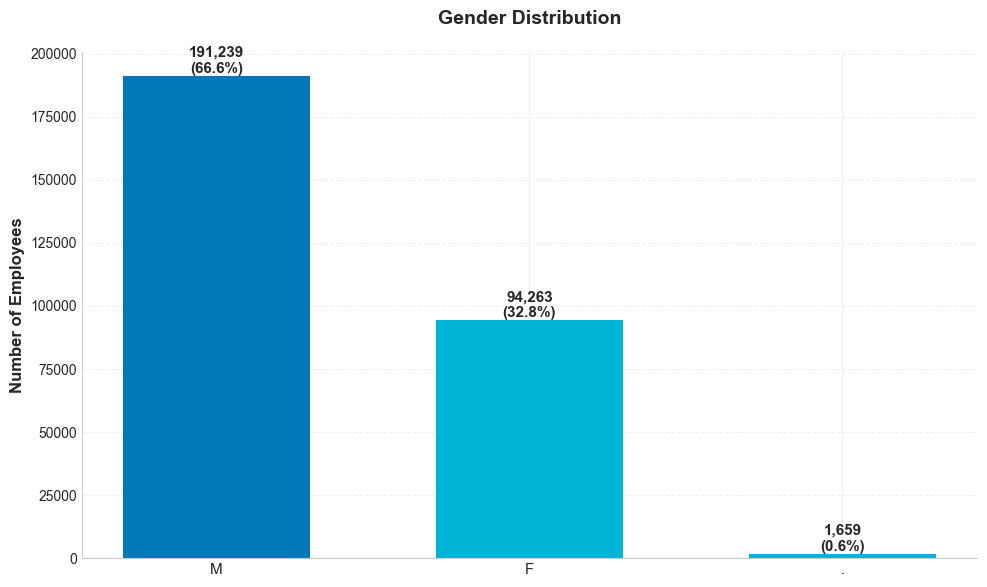

✓ Saved: output/company_overview/01_gender_distribution.png


In [43]:
# Visualize Gender Distribution - McKinsey Style
if gender_col:
    fig, ax = plt.subplots(figsize=(10, 6))
    
    gender_data = df[gender_col].value_counts()
    colors = [MCKINSEY_BLUE if i == 0 else MCKINSEY_LIGHT_BLUE for i in range(len(gender_data))]
    
    bars = ax.bar(range(len(gender_data)), gender_data.values, color=colors, width=0.6)
    
    # Add value labels on bars
    for i, (bar, val) in enumerate(zip(bars, gender_data.values)):
        height = bar.get_height()
        pct = (val / gender_data.sum() * 100)
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{val:,}\n({pct:.1f}%)',
                ha='center', va='bottom', fontsize=11, fontweight='bold')
    
    ax.set_xticks(range(len(gender_data)))
    ax.set_xticklabels(gender_data.index, fontsize=11)
    ax.set_ylabel('Number of Employees', fontsize=12, fontweight='bold')
    ax.set_title('Gender Distribution', fontsize=14, fontweight='bold', pad=20)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    
    plt.tight_layout()
    plt.savefig(f'{output_dir}/01_gender_distribution.png', dpi=300, bbox_inches='tight')
    plt.show()
    print(f"✓ Saved: {output_dir}/01_gender_distribution.png")

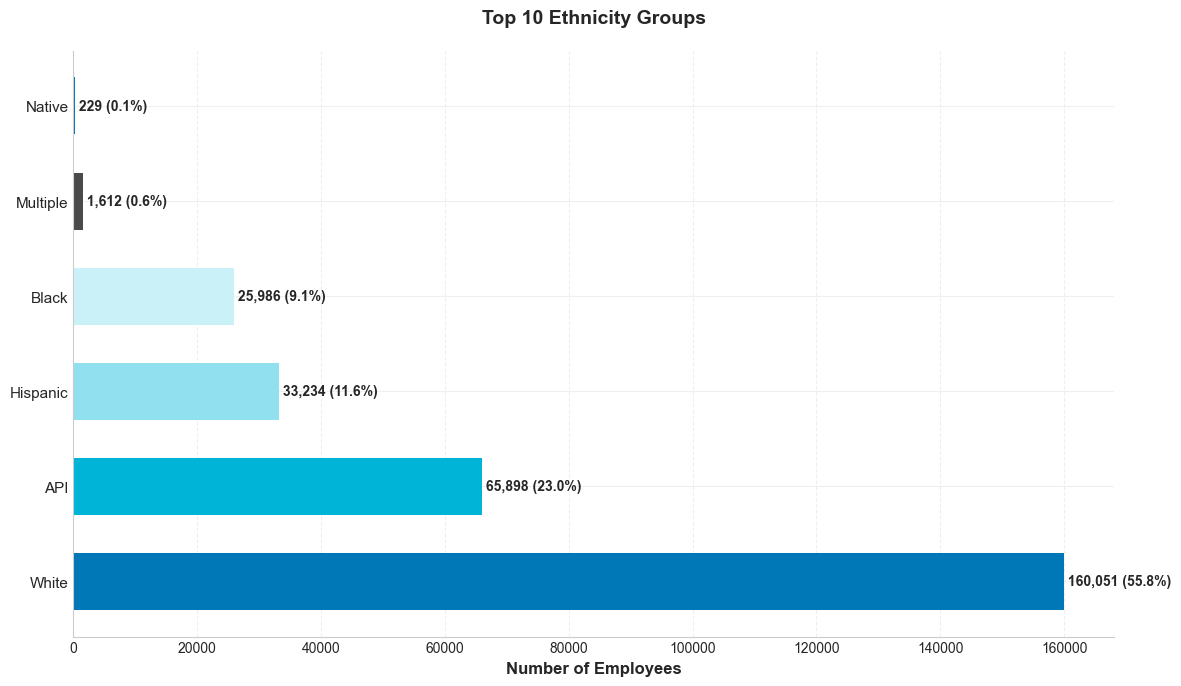

✓ Saved: output/company_overview/02_ethnicity_distribution.png


In [44]:
# Visualize Ethnicity Distribution - McKinsey Style
if ethnicity_col:
    fig, ax = plt.subplots(figsize=(12, 7))
    
    ethnicity_data = df[ethnicity_col].value_counts().head(10)
    colors = [MCKINSEY_PALETTE[i % len(MCKINSEY_PALETTE)] for i in range(len(ethnicity_data))]
    
    bars = ax.barh(range(len(ethnicity_data)), ethnicity_data.values, color=colors, height=0.6)
    
    # Add value labels
    for i, (bar, val) in enumerate(zip(bars, ethnicity_data.values)):
        width = bar.get_width()
        pct = (val / df[ethnicity_col].notna().sum() * 100)
        ax.text(width, bar.get_y() + bar.get_height()/2.,
                f' {val:,} ({pct:.1f}%)',
                ha='left', va='center', fontsize=10, fontweight='bold')
    
    ax.set_yticks(range(len(ethnicity_data)))
    ax.set_yticklabels(ethnicity_data.index, fontsize=11)
    ax.set_xlabel('Number of Employees', fontsize=12, fontweight='bold')
    ax.set_title('Top 10 Ethnicity Groups', fontsize=14, fontweight='bold', pad=20)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='x', alpha=0.3, linestyle='--')
    
    plt.tight_layout()
    plt.savefig(f'{output_dir}/02_ethnicity_distribution.png', dpi=300, bbox_inches='tight')
    plt.show()
    print(f"✓ Saved: {output_dir}/02_ethnicity_distribution.png")

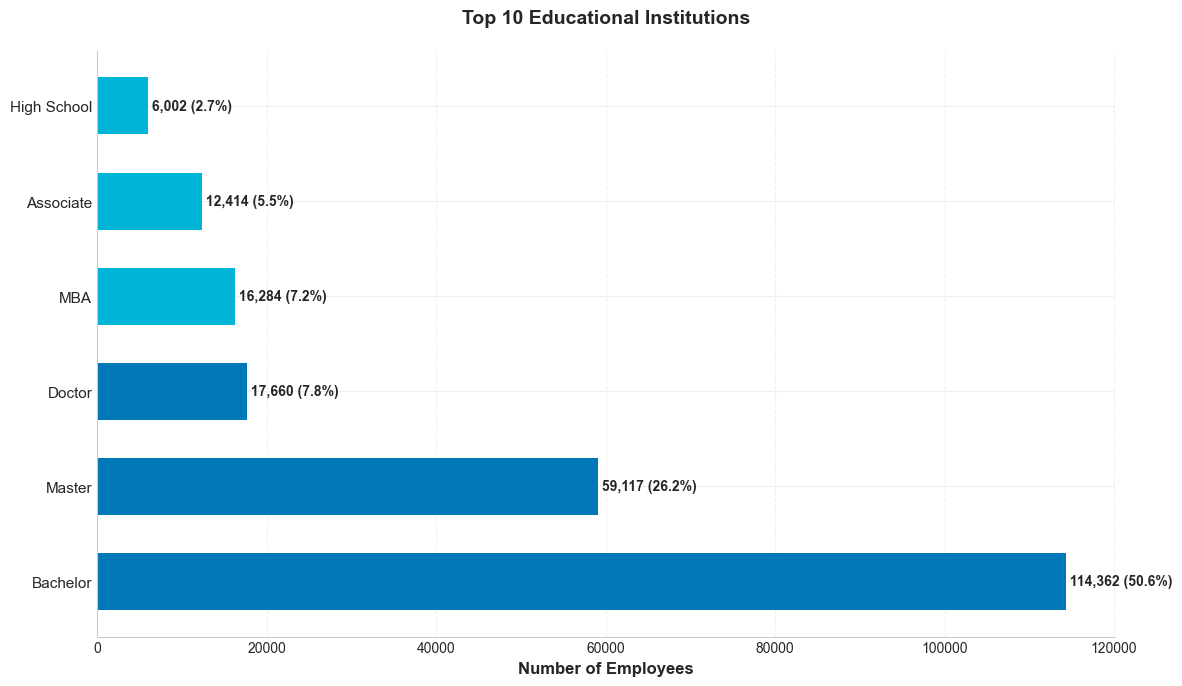

✓ Saved: output/company_overview/03_education_distribution.png


In [45]:
# Visualize Education Distribution - McKinsey Style
if education_col:
    fig, ax = plt.subplots(figsize=(12, 7))
    
    education_data = df[education_col].value_counts().head(10)
    colors = [MCKINSEY_BLUE if i < 3 else MCKINSEY_LIGHT_BLUE for i in range(len(education_data))]
    
    bars = ax.barh(range(len(education_data)), education_data.values, color=colors, height=0.6)
    
    # Add value labels
    for i, (bar, val) in enumerate(zip(bars, education_data.values)):
        width = bar.get_width()
        pct = (val / df[education_col].notna().sum() * 100)
        ax.text(width, bar.get_y() + bar.get_height()/2.,
                f' {val:,} ({pct:.1f}%)',
                ha='left', va='center', fontsize=10, fontweight='bold')
    
    ax.set_yticks(range(len(education_data)))
    ax.set_yticklabels(education_data.index, fontsize=11)
    ax.set_xlabel('Number of Employees', fontsize=12, fontweight='bold')
    ax.set_title('Top 10 Educational Institutions', fontsize=14, fontweight='bold', pad=20)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='x', alpha=0.3, linestyle='--')
    
    plt.tight_layout()
    plt.savefig(f'{output_dir}/03_education_distribution.png', dpi=300, bbox_inches='tight')
    plt.show()
    print(f"✓ Saved: {output_dir}/03_education_distribution.png")

---
## Section 1: Position Analysis
### Most Common Job Titles

In [46]:
# Use O*NET codes for position analysis
position_code_col = 'onet_code'
position_title_col = 'onet_title'

if position_code_col in df.columns and position_title_col in df.columns:
    print("=" * 60)
    print("TOP 20 MOST COMMON POSITIONS")
    print("=" * 60)
    
    # Group by onet_code and get the first onet_title for each code
    position_mapping = df.groupby(position_code_col)[position_title_col].first()
    position_counts = df[position_code_col].value_counts().head(20)
    position_pct = (df[position_code_col].value_counts(normalize=True) * 100).round(2).head(20)
    
    # Create summary with titles
    position_summary = pd.DataFrame({
        'Position': [position_mapping[code] for code in position_counts.index],
        'Count': position_counts.values,
        'Percentage': position_pct.values
    })
    
    display(position_summary)
    
    print(f"\n📊 Total unique positions (O*NET codes): {df[position_code_col].nunique():,}")
else:
    print("⚠️ Position columns (onet_code, onet_title) not found in dataset")

TOP 20 MOST COMMON POSITIONS


,Position,Count,Percentage
0,Computer User Support Specialists,27328,9.52
1,Software Developers,25841,9.0
2,Retail Salespersons,13191,4.59
3,"Sales Representatives, Wholesale and Manufactu...",10734,3.74
4,Customer Service Representatives,10595,3.69
5,Computer Systems Engineers/Architects,8487,2.96
6,Microsystems Engineers,7693,2.68
7,Information Technology Project Managers,6478,2.26
8,Sales Engineers,5679,1.98
9,"Engineers, All Other",5272,1.84



📊 Total unique positions (O*NET codes): 803


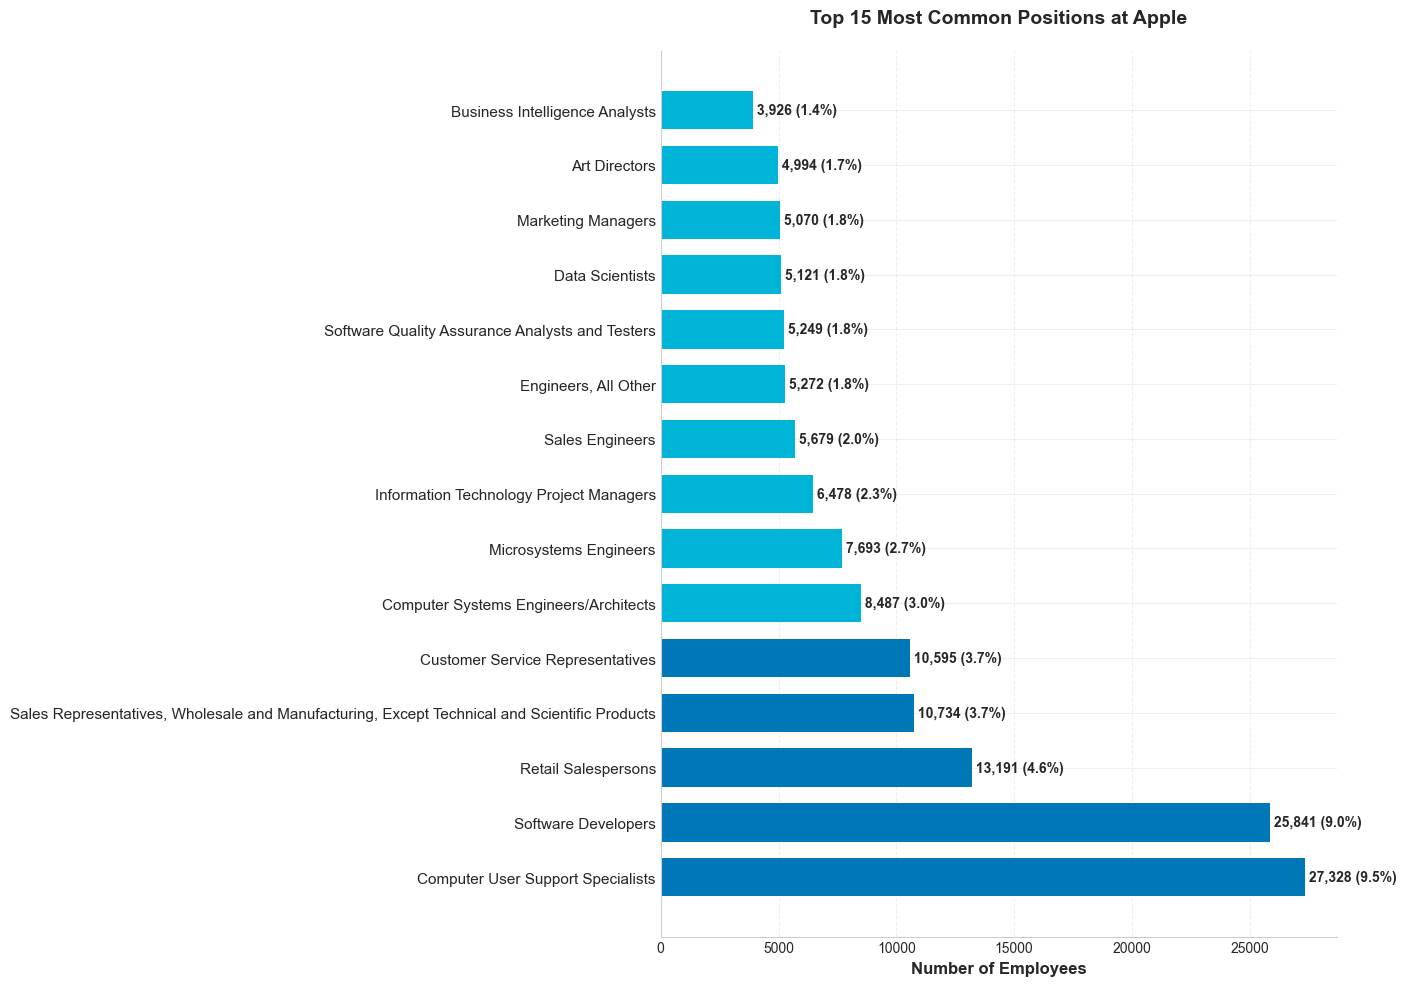

✓ Saved: output/company_overview/04_top_positions.png


In [47]:
# Visualize Top Positions - McKinsey Style
if position_code_col in df.columns and position_title_col in df.columns:
    fig, ax = plt.subplots(figsize=(14, 10))
    
    # Get top 15 positions by onet_code
    top_codes = df[position_code_col].value_counts().head(15)
    position_mapping = df.groupby(position_code_col)[position_title_col].first()
    position_titles = [position_mapping[code] for code in top_codes.index]
    
    colors = [MCKINSEY_BLUE if i < 5 else MCKINSEY_LIGHT_BLUE for i in range(len(top_codes))]
    
    bars = ax.barh(range(len(top_codes)), top_codes.values, color=colors, height=0.7)
    
    # Add value labels
    for i, (bar, val) in enumerate(zip(bars, top_codes.values)):
        width = bar.get_width()
        pct = (val / len(df) * 100)
        ax.text(width, bar.get_y() + bar.get_height()/2.,
                f' {val:,} ({pct:.1f}%)',
                ha='left', va='center', fontsize=10, fontweight='bold')
    
    ax.set_yticks(range(len(top_codes)))
    ax.set_yticklabels(position_titles, fontsize=11)
    ax.set_xlabel('Number of Employees', fontsize=12, fontweight='bold')
    ax.set_title('Top 15 Most Common Positions at Apple', fontsize=14, fontweight='bold', pad=20)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='x', alpha=0.3, linestyle='--')

    plt.tight_layout()
    plt.savefig(f'{output_dir}/04_top_positions.png', dpi=300, bbox_inches='tight')
    plt.show()
    print(f"✓ Saved: {output_dir}/04_top_positions.png")

---
## Section 2: Geographic Analysis
### Employee Location Mapping

In [48]:
# Load world cities data for coordinates
import zipfile

print("Loading world cities database...")
with zipfile.ZipFile('data/simplemaps_worldcities_basicv1.901.zip', 'r') as zip_ref:
    # Find the CSV file in the zip
    csv_files = [f for f in zip_ref.namelist() if f.endswith('.csv')]
    if csv_files:
        with zip_ref.open(csv_files[0]) as csv_file:
            cities_df = pd.read_csv(csv_file)
            print(f"✓ Loaded {len(cities_df):,} cities")
            print(f"\nCities columns: {cities_df.columns.tolist()}")
            display(cities_df.head())

Loading world cities database...
✓ Loaded 48,059 cities

Cities columns: ['city', 'city_ascii', 'lat', 'lng', 'country', 'iso2', 'iso3', 'admin_name', 'capital', 'population', 'id']


,city,city_ascii,lat,lng,country,iso2,iso3,admin_name,capital,population,id
0,Tokyo,Tokyo,35.6870,139.7495,Japan,JP,JPN,Tōkyō,primary,37785000.0,1392685764
1,Jakarta,Jakarta,-6.1750,106.8275,Indonesia,ID,IDN,Jakarta,primary,33756000.0,1360771077
2,Delhi,Delhi,28.6100,77.2300,India,IN,IND,Delhi,admin,32226000.0,1356872604
3,Guangzhou,Guangzhou,23.1300,113.2600,China,CN,CHN,Guangdong,admin,26940000.0,1156237133
4,Mumbai,Mumbai,19.0761,72.8775,India,IN,IND,Mahārāshtra,admin,24973000.0,1356226629


In [49]:
# Find city column in employee data
city_col = None
for col in df.columns:
    if 'city' in col.lower() or 'location' in col.lower():
        city_col = col
        break

if city_col:
    print(f"Found city column: {city_col}")
    print(f"\nTop 10 cities in employee data:")
    display(df[city_col].value_counts().head(10))
else:
    print("⚠️ City column not found. Will check for other location columns...")
    location_cols = [col for col in df.columns if any(kw in col.lower() for kw in ['city', 'location', 'place', 'region'])]
    print(f"Potential location columns: {location_cols}")

Found city column: location_raw

Top 10 cities in employee data:


location_raw
Cupertino, California, United States      28953
United States                             20806
San Francisco Bay Area                    13925
Cupertino, CA                             11216
Austin, Texas, United States              11204
Cupertino, California                      6894
Sunnyvale, California, United States       6176
Cupertino                                  4270
Los Angeles, California, United States     3912
San Diego, California, United States       3892
Name: count, dtype: Int64

In [50]:
# Merge employee data with city coordinates
if city_col:
    # Prepare city names for matching
    df['city_clean'] = df[city_col].astype(str).str.strip().str.lower()
    cities_df['city_clean'] = cities_df['city'].astype(str).str.strip().str.lower()
    
    # Merge on city name
    df_geo = df.merge(
        cities_df[['city_clean', 'lat', 'lng', 'country']],
        on='city_clean',
        how='left'
    )
    
    matched = df_geo['lat'].notna().sum()
    match_rate = (matched / len(df_geo) * 100)
    
    print(f"\n📍 Successfully matched {matched:,} / {len(df_geo):,} employees ({match_rate:.1f}%)")
    print(f"\nTop 10 employee locations:")
    location_counts = df_geo[df_geo['lat'].notna()].groupby(city_col).size().sort_values(ascending=False).head(10)
    display(location_counts)
else:
    print("⚠️ Cannot proceed with geographic analysis without city data")


📍 Successfully matched 11,031 / 289,845 employees (3.8%)

Top 10 employee locations:


location_raw
Cupertino        4270
San Francisco    1010
Sunnyvale         707
Santa Clara       344
California        305
Austin            240
San Diego         237
Chicago           199
Seattle           186
Florida           165
dtype: int64

In [51]:
# Create interactive map with employee locations - McKinsey Style (USA only)
if city_col and 'lat' in df_geo.columns:
    # Aggregate by location
    map_data = df_geo[df_geo['lat'].notna()].groupby(
        [city_col, 'lat', 'lng']
    ).size().reset_index(name='employee_count')
    
    # Create map using scatter_mapbox for actual map visualization
    fig = px.scatter_mapbox(
        map_data,
        lat='lat',
        lon='lng',
        size='employee_count',
        hover_name=city_col,
        hover_data={
            'employee_count': ':,',
            'lat': ':.4f',
            'lng': ':.4f'
        },
        color='employee_count',
        color_continuous_scale=[
            [0, '#FFE5E5'],
            [0.5, '#FF6B6B'],
            [1, '#CC0000']
        ],
        size_max=50,
        zoom=3,
        center={'lat': 37.0902, 'lon': -95.7129},  # Center of USA
        title='<b>Apple Employee Geographic Distribution (USA)</b>',
        mapbox_style='open-street-map'  # Use OpenStreetMap for free map tiles
    )
    
    fig.update_layout(
        font=dict(family="Arial, sans-serif", size=12),
        title_font=dict(size=16, color='#4A4A4A'),
        coloraxis_colorbar=dict(
            title="Employees",
            tickformat=','
        ),
        height=700,
        margin={"r":0,"t":50,"l":0,"b":0}
    )
    
    # fig.write_html(f'{output_dir}/05_employee_geographic_map.html')
    # fig.show()
    # print(f"✓ Saved: {output_dir}/05_employee_geographic_map.html")

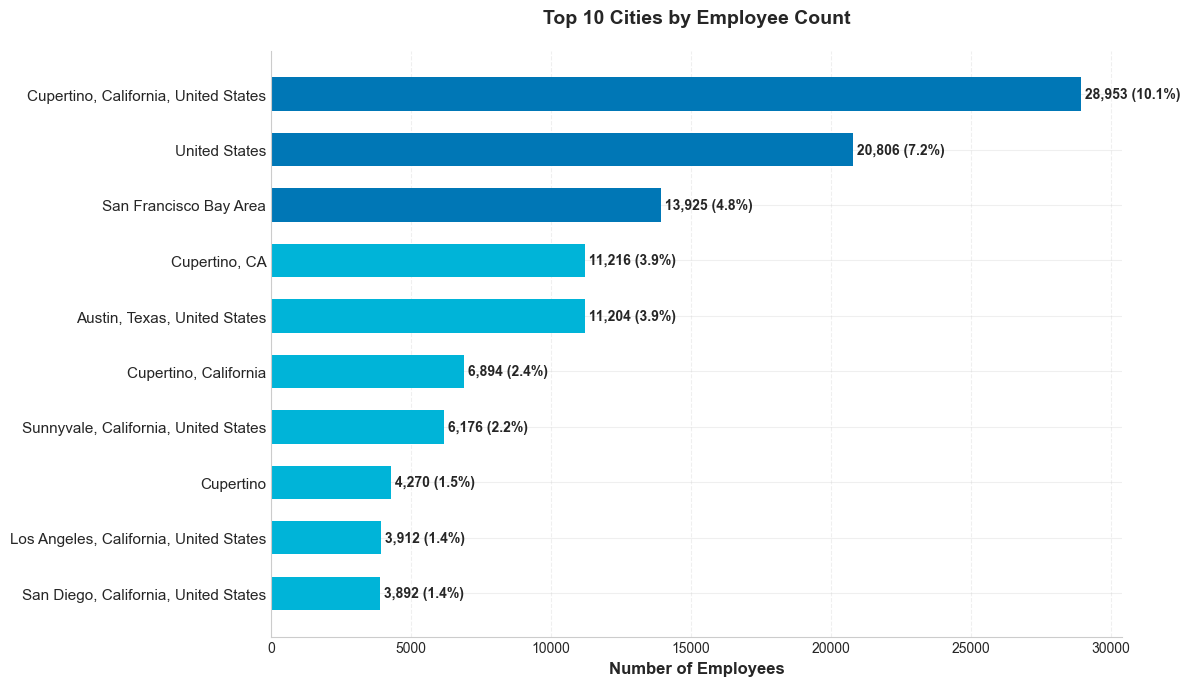

✓ Saved: output/company_overview/06_top_cities.png


In [52]:
# Top 10 cities visualization - McKinsey Style
if city_col:
    fig, ax = plt.subplots(figsize=(12, 7))
    
    city_data = df[city_col].value_counts().head(10)
    colors = [MCKINSEY_BLUE if i < 3 else MCKINSEY_LIGHT_BLUE for i in range(len(city_data))]
    
    bars = ax.barh(range(len(city_data)), city_data.values, color=colors, height=0.6)
    
    # Add value labels
    for i, (bar, val) in enumerate(zip(bars, city_data.values)):
        width = bar.get_width()
        pct = (val / len(df) * 100)
        ax.text(width, bar.get_y() + bar.get_height()/2.,
                f' {val:,} ({pct:.1f}%)',
                ha='left', va='center', fontsize=10, fontweight='bold')
    
    ax.set_yticks(range(len(city_data)))
    ax.set_yticklabels(city_data.index, fontsize=11)
    ax.set_xlabel('Number of Employees', fontsize=12, fontweight='bold')
    ax.set_title('Top 10 Cities by Employee Count', fontsize=14, fontweight='bold', pad=20)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='x', alpha=0.3, linestyle='--')
    ax.invert_yaxis()
    
    plt.tight_layout()
    plt.savefig(f'{output_dir}/06_top_cities.png', dpi=300, bbox_inches='tight')
    plt.show()
    print(f"✓ Saved: {output_dir}/06_top_cities.png")

---
## Section 3: Remote Work Analysis
### Remote Suitability Distribution

In [53]:
# Find remote work column
remote_col = None
for col in df.columns:
    if any(keyword in col.lower() for keyword in ['remote', 'wfh', 'work_from_home', 'telework']):
        remote_col = col
        break

if remote_col:
    print("=" * 60)
    print("REMOTE WORK SUITABILITY ANALYSIS")
    print("=" * 60)
    
    remote_counts = df[remote_col].value_counts()
    remote_pct = (df[remote_col].value_counts(normalize=True) * 100).round(2)
    
    remote_summary = pd.DataFrame({
        'Count': remote_counts,
        'Percentage': remote_pct
    })
    
    display(remote_summary)
    
    print(f"\n📊 Remote work data available for: {df[remote_col].notna().sum():,} employees")
else:
    print("⚠️ Remote work column not found in dataset")
    print("Searching for related columns...")
    work_cols = [col for col in df.columns if any(kw in col.lower() for kw in ['work', 'office', 'location'])]
    print(f"Potential work-related columns: {work_cols}")

REMOTE WORK SUITABILITY ANALYSIS


,Count,Percentage
remote_suitability,,
0.5,73657,25.65
0.051249,15885,5.53
0.177066,11877,4.14
0.461758,10077,3.51
0.104867,9577,3.34
...,...,...
0.912205,1,0.0
0.383879,1,0.0
0.145859,1,0.0



📊 Remote work data available for: 287,161 employees


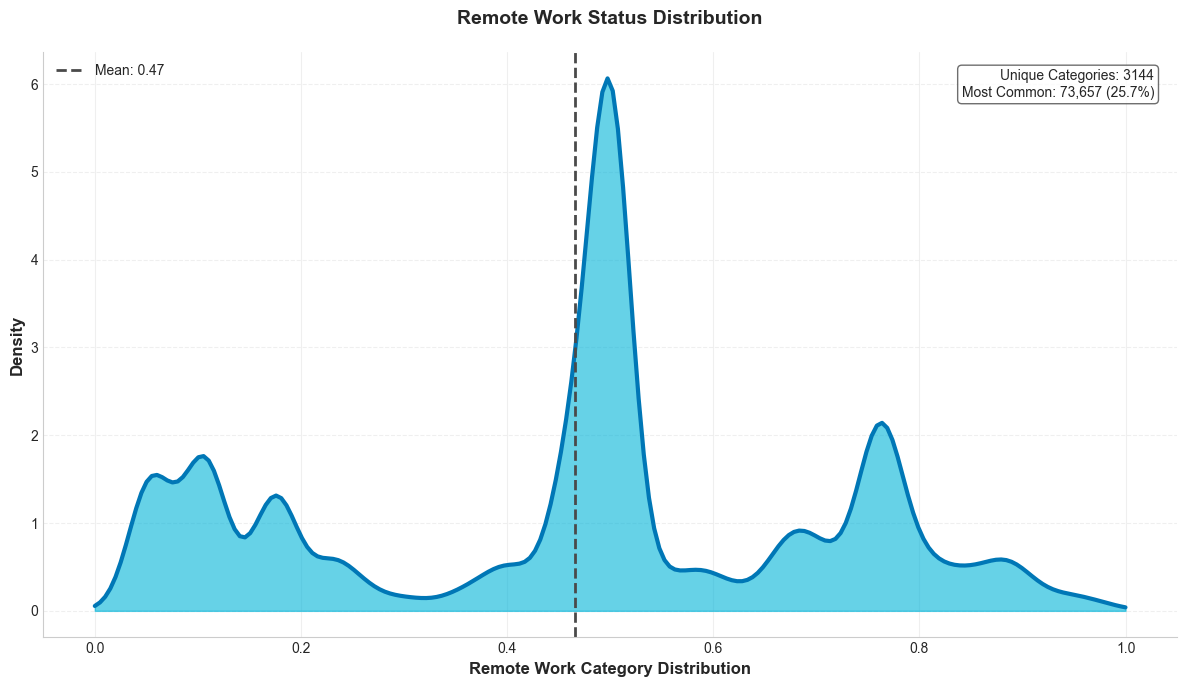

✓ Saved: output/company_overview/07_remote_work_distribution.png


In [54]:
3
if remote_col:
    # Try different visualizations based on data type
    if df[remote_col].dtype in ['int64', 'float64']:
        # Numeric remote suitability score
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
        
        # Distribution plot
        ax1.hist(df[remote_col].dropna(), bins=30, color=MCKINSEY_BLUE, 
                edgecolor='white', alpha=0.8)
        ax1.axvline(df[remote_col].mean(), color=MCKINSEY_GRAY, 
                   linestyle='--', linewidth=2, label=f'Mean: {df[remote_col].mean():.2f}')
        ax1.axvline(df[remote_col].median(), color='#FF6B6B', 
                   linestyle='--', linewidth=2, label=f'Median: {df[remote_col].median():.2f}')
        ax1.set_xlabel('Remote Suitability Score', fontsize=12, fontweight='bold')
        ax1.set_ylabel('Frequency', fontsize=12, fontweight='bold')
        ax1.set_title('Remote Work Suitability Distribution', fontsize=14, fontweight='bold', pad=20)
        ax1.spines['top'].set_visible(False)
        ax1.spines['right'].set_visible(False)
        ax1.legend()
        ax1.grid(axis='y', alpha=0.3, linestyle='--')
        
        # Box plot
        bp = ax2.boxplot(df[remote_col].dropna(), vert=True, patch_artist=True,
                        widths=0.5,
                        boxprops=dict(facecolor=MCKINSEY_LIGHT_BLUE, edgecolor=MCKINSEY_BLUE, linewidth=2),
                        whiskerprops=dict(color=MCKINSEY_BLUE, linewidth=2),
                        capprops=dict(color=MCKINSEY_BLUE, linewidth=2),
                        medianprops=dict(color='#FF6B6B', linewidth=2.5),
                        flierprops=dict(marker='o', markerfacecolor=MCKINSEY_GRAY, 
                                       markersize=6, alpha=0.5))
        ax2.set_ylabel('Remote Suitability Score', fontsize=12, fontweight='bold')
        ax2.set_title('Remote Work Suitability Range', fontsize=14, fontweight='bold', pad=20)
        ax2.spines['top'].set_visible(False)
        ax2.spines['right'].set_visible(False)
        ax2.grid(axis='y', alpha=0.3, linestyle='--')
        ax2.set_xticklabels(['All Employees'])
        
        plt.tight_layout()
        plt.savefig(f'{output_dir}/07_remote_work_numeric.png', dpi=300, bbox_inches='tight')
        plt.show()
        print(f"✓ Saved: {output_dir}/07_remote_work_numeric.png")
        
        # Summary statistics
        print(f"\n📊 Remote Suitability Statistics:")
        print(f"   Mean: {df[remote_col].mean():.2f}")
        print(f"   Median: {df[remote_col].median():.2f}")
        print(f"   Std Dev: {df[remote_col].std():.2f}")
        print(f"   Min: {df[remote_col].min():.2f}")
        print(f"   Max: {df[remote_col].max():.2f}")
        
    else:
        # Categorical remote work data - use density/distribution plot
        fig, ax = plt.subplots(figsize=(12, 7))
        
        # Convert categorical to numeric for density plot
        remote_data_clean = df[remote_col].dropna()
        
        # Create a density plot
        from scipy import stats
        
        # If data is categorical, convert to numeric codes
        if remote_data_clean.dtype == 'object':
            remote_numeric = pd.Categorical(remote_data_clean).codes
        else:
            remote_numeric = remote_data_clean
        
        # Create density plot
        density = stats.gaussian_kde(remote_numeric)
        x_range = np.linspace(remote_numeric.min(), remote_numeric.max(), 200)
        
        ax.fill_between(x_range, density(x_range), alpha=0.6, color=MCKINSEY_LIGHT_BLUE)
        ax.plot(x_range, density(x_range), color=MCKINSEY_BLUE, linewidth=3)
        
        # Add mean line
        mean_val = remote_numeric.mean()
        ax.axvline(mean_val, color=MCKINSEY_GRAY, linestyle='--', linewidth=2, 
                   label=f'Mean: {mean_val:.2f}')
        
        ax.set_xlabel('Remote Work Category Distribution', fontsize=12, fontweight='bold')
        ax.set_ylabel('Density', fontsize=12, fontweight='bold')
        ax.set_title('Remote Work Status Distribution', fontsize=14, fontweight='bold', pad=20)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.grid(axis='y', alpha=0.3, linestyle='--')
        ax.legend()
        
        # Add summary statistics as text
        unique_count = df[remote_col].nunique()
        most_common = df[remote_col].value_counts().iloc[0]
        most_common_pct = (most_common / len(df[remote_col].dropna()) * 100)
        
        stats_text = f'Unique Categories: {unique_count}\nMost Common: {most_common:,} ({most_common_pct:.1f}%)'
        ax.text(0.98, 0.97, stats_text, transform=ax.transAxes,
                verticalalignment='top', horizontalalignment='right',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor=MCKINSEY_GRAY),
                fontsize=10)
        
        plt.tight_layout()
        plt.savefig(f'{output_dir}/07_remote_work_distribution.png', dpi=300, bbox_inches='tight')
        plt.show()
        print(f"✓ Saved: {output_dir}/07_remote_work_distribution.png")

---
## Section 4: Compensation Analysis
### Salary Distribution and Insights

In [55]:
# Find salary column
salary_col = None
for col in df.columns:
    if any(keyword in col.lower() for keyword in ['salary', 'compensation', 'pay', 'wage', 'income']):
        salary_col = col
        break

if salary_col:
    print("=" * 60)
    print("SALARY ANALYSIS")
    print("=" * 60)
    
    salary_data = df[salary_col].dropna()
    
    print(f"\n📊 Salary Statistics:")
    print(f"   Count: {len(salary_data):,}")
    print(f"   Mean: ${salary_data.mean():,.2f}")
    print(f"   Median: ${salary_data.median():,.2f}")
    print(f"   Std Dev: ${salary_data.std():,.2f}")
    print(f"   Min: ${salary_data.min():,.2f}")
    print(f"   25th percentile: ${salary_data.quantile(0.25):,.2f}")
    print(f"   75th percentile: ${salary_data.quantile(0.75):,.2f}")
    print(f"   Max: ${salary_data.max():,.2f}")
else:
    print("⚠️ Salary column not found in dataset")
    comp_cols = [col for col in df.columns if any(kw in col.lower() for kw in ['salary', 'pay', 'comp', 'wage', 'income'])]
    print(f"Potential compensation columns: {comp_cols}")

SALARY ANALYSIS

📊 Salary Statistics:
   Count: 287,058
   Mean: $111,736.83
   Median: $95,002.83
   Std Dev: $67,970.43
   Min: $2,600.38
   25th percentile: $56,021.85
   75th percentile: $156,580.32
   Max: $597,507.92


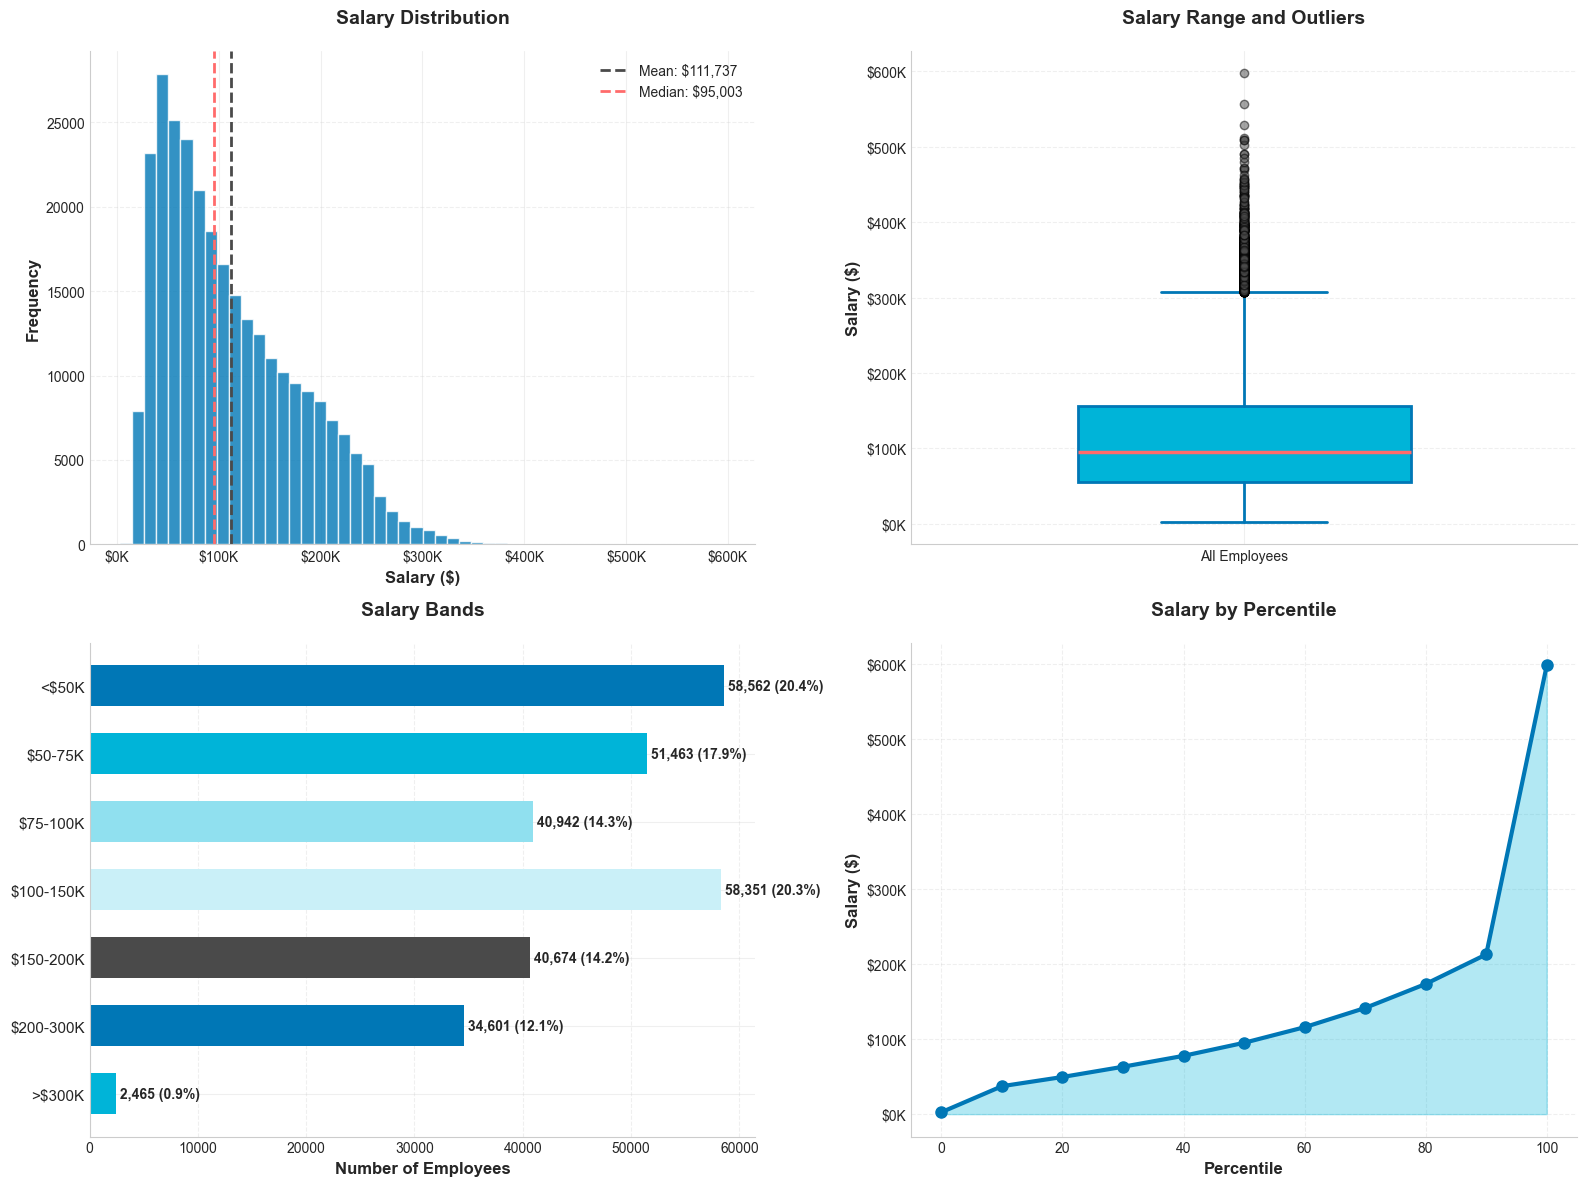

✓ Saved: output/company_overview/08_salary_distribution.png


In [56]:
# Visualize Salary Distribution - McKinsey Style
if salary_col:
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))
    
    salary_data = df[salary_col].dropna()
    
    # 1. Histogram
    ax1.hist(salary_data, bins=50, color=MCKINSEY_BLUE, edgecolor='white', alpha=0.8)
    ax1.axvline(salary_data.mean(), color=MCKINSEY_GRAY, 
               linestyle='--', linewidth=2, label=f'Mean: ${salary_data.mean():,.0f}')
    ax1.axvline(salary_data.median(), color='#FF6B6B', 
               linestyle='--', linewidth=2, label=f'Median: ${salary_data.median():,.0f}')
    ax1.set_xlabel('Salary ($)', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Frequency', fontsize=12, fontweight='bold')
    ax1.set_title('Salary Distribution', fontsize=14, fontweight='bold', pad=20)
    ax1.spines['top'].set_visible(False)
    ax1.spines['right'].set_visible(False)
    ax1.legend()
    ax1.grid(axis='y', alpha=0.3, linestyle='--')
    ax1.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1000:.0f}K'))
    
    # 2. Box plot
    bp = ax2.boxplot(salary_data, vert=True, patch_artist=True,
                    widths=0.5,
                    boxprops=dict(facecolor=MCKINSEY_LIGHT_BLUE, edgecolor=MCKINSEY_BLUE, linewidth=2),
                    whiskerprops=dict(color=MCKINSEY_BLUE, linewidth=2),
                    capprops=dict(color=MCKINSEY_BLUE, linewidth=2),
                    medianprops=dict(color='#FF6B6B', linewidth=2.5),
                    flierprops=dict(marker='o', markerfacecolor=MCKINSEY_GRAY, 
                                   markersize=6, alpha=0.5))
    ax2.set_ylabel('Salary ($)', fontsize=12, fontweight='bold')
    ax2.set_title('Salary Range and Outliers', fontsize=14, fontweight='bold', pad=20)
    ax2.spines['top'].set_visible(False)
    ax2.spines['right'].set_visible(False)
    ax2.grid(axis='y', alpha=0.3, linestyle='--')
    ax2.set_xticklabels(['All Employees'])
    ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1000:.0f}K'))
    
    # 3. Salary bands
    bins = [0, 50000, 75000, 100000, 150000, 200000, 300000, salary_data.max()]
    labels = ['<$50K', '$50-75K', '$75-100K', '$100-150K', '$150-200K', '$200-300K', '>$300K']
    salary_bands = pd.cut(salary_data, bins=bins, labels=labels)
    band_counts = salary_bands.value_counts().sort_index()
    
    colors = [MCKINSEY_PALETTE[i % len(MCKINSEY_PALETTE)] for i in range(len(band_counts))]
    bars = ax3.barh(range(len(band_counts)), band_counts.values, color=colors, height=0.6)
    
    for i, (bar, val) in enumerate(zip(bars, band_counts.values)):
        width = bar.get_width()
        pct = (val / len(salary_data) * 100)
        ax3.text(width, bar.get_y() + bar.get_height()/2.,
                f' {val:,} ({pct:.1f}%)',
                ha='left', va='center', fontsize=10, fontweight='bold')
    
    ax3.set_yticks(range(len(band_counts)))
    ax3.set_yticklabels(band_counts.index, fontsize=11)
    ax3.set_xlabel('Number of Employees', fontsize=12, fontweight='bold')
    ax3.set_title('Salary Bands', fontsize=14, fontweight='bold', pad=20)
    ax3.spines['top'].set_visible(False)
    ax3.spines['right'].set_visible(False)
    ax3.grid(axis='x', alpha=0.3, linestyle='--')
    ax3.invert_yaxis()
    
    # 4. Percentile chart
    percentiles = np.arange(0, 101, 10)
    percentile_values = [salary_data.quantile(p/100) for p in percentiles]
    
    ax4.plot(percentiles, percentile_values, color=MCKINSEY_BLUE, linewidth=3, marker='o', markersize=8)
    ax4.fill_between(percentiles, percentile_values, alpha=0.3, color=MCKINSEY_LIGHT_BLUE)
    ax4.set_xlabel('Percentile', fontsize=12, fontweight='bold')
    ax4.set_ylabel('Salary ($)', fontsize=12, fontweight='bold')
    ax4.set_title('Salary by Percentile', fontsize=14, fontweight='bold', pad=20)
    ax4.spines['top'].set_visible(False)
    ax4.spines['right'].set_visible(False)
    ax4.grid(alpha=0.3, linestyle='--')
    ax4.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1000:.0f}K'))
    
    plt.tight_layout()
    plt.savefig(f'{output_dir}/08_salary_distribution.png', dpi=300, bbox_inches='tight')
    plt.show()
    print(f"✓ Saved: {output_dir}/08_salary_distribution.png")


=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
AVERAGE SALARY BY TOP POSITIONS


,Position,mean,median,count
onet_code,,,,
15-1252.00,Software Developers,175143.06,190597.29,25830
15-2051.00,Data Scientists,172141.55,187688.85,5120
17-2199.00,"Engineers, All Other",162273.15,168643.77,5272
15-1299.09,Information Technology Project Managers,147222.2,151051.5,6476
15-1299.08,Computer Systems Engineers/Architects,139752.14,141036.32,8486
17-2199.06,Microsystems Engineers,138730.36,117231.58,7691
11-2021.00,Marketing Managers,128572.31,111135.93,5067
15-1253.00,Software Quality Assurance Analysts and Testers,128497.85,133149.55,5247
27-1011.00,Art Directors,116245.3,92883.73,4991


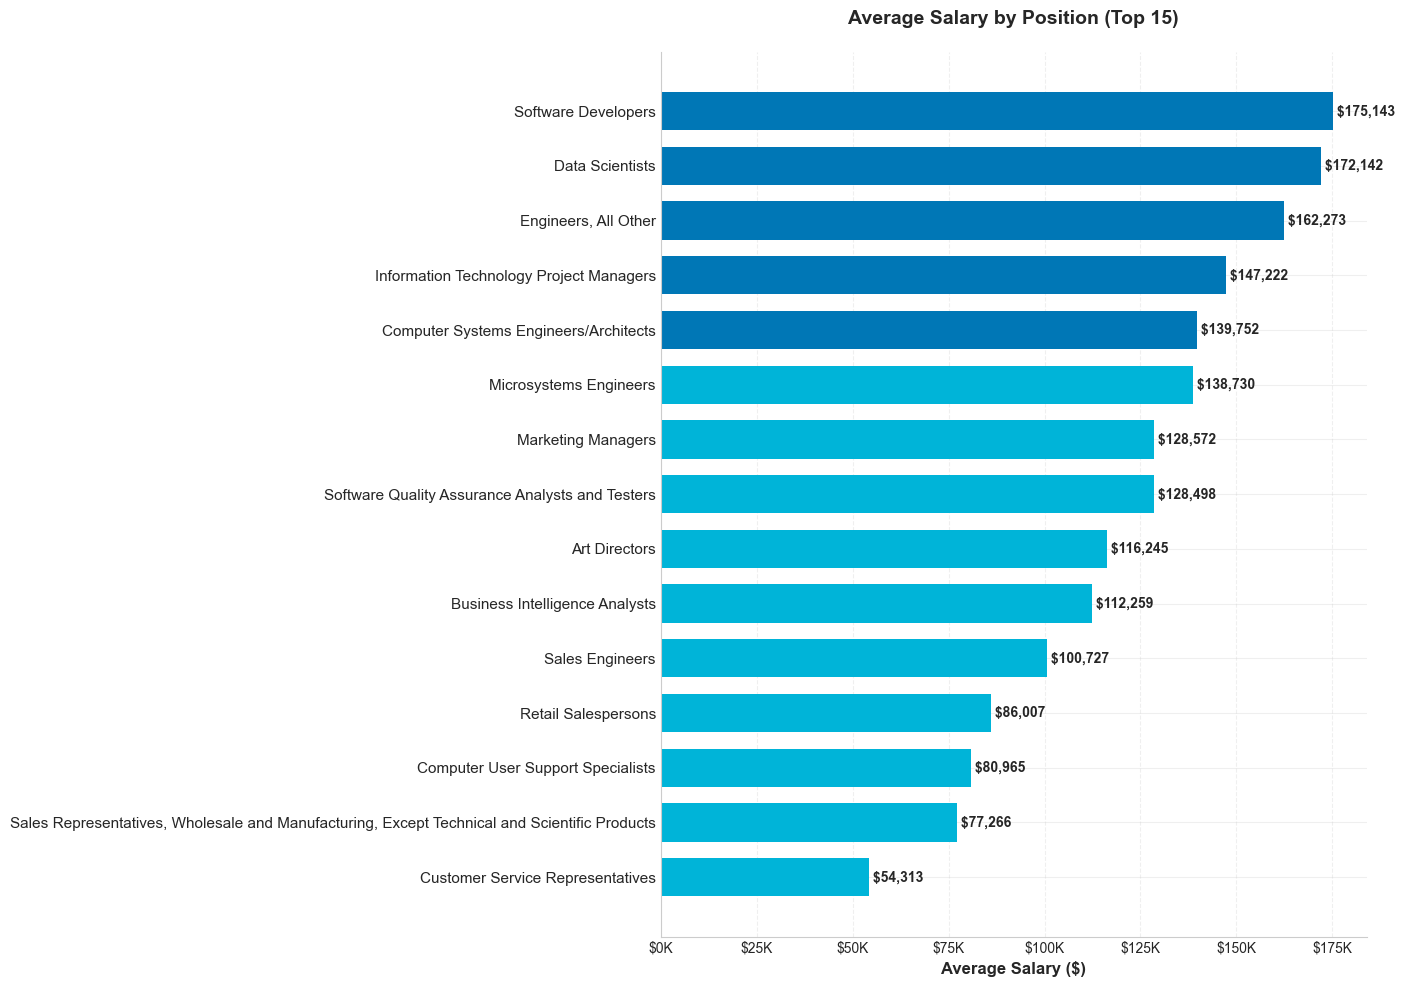

✓ Saved: output/company_overview/09_salary_by_position.png


In [57]:
# Salary by Position (if both columns exist)
if salary_col and position_code_col in df.columns and position_title_col in df.columns:
    print("\n=" * 60)
    print("AVERAGE SALARY BY TOP POSITIONS")
    print("=" * 60)
    
    # Get top 15 positions by count (using onet_code)
    top_position_codes = df[position_code_col].value_counts().head(15).index
    salary_by_position = df[df[position_code_col].isin(top_position_codes)].groupby(position_code_col)[salary_col].agg(['mean', 'median', 'count']).sort_values('mean', ascending=False)
    
    salary_by_position['mean'] = salary_by_position['mean'].round(2)
    salary_by_position['median'] = salary_by_position['median'].round(2)
    
    # Add position titles to the display
    position_mapping = df.groupby(position_code_col)[position_title_col].first()
    salary_by_position['Position'] = [position_mapping[code] for code in salary_by_position.index]
    salary_by_position = salary_by_position[['Position', 'mean', 'median', 'count']]
    
    display(salary_by_position)
    
    # Visualize
    fig, ax = plt.subplots(figsize=(14, 10))
    
    position_codes = salary_by_position.head(15).index
    position_titles = [position_mapping[code] for code in position_codes]
    means = salary_by_position.head(15)['mean'].values
    
    colors = [MCKINSEY_BLUE if i < 5 else MCKINSEY_LIGHT_BLUE for i in range(len(position_codes))]
    bars = ax.barh(range(len(position_codes)), means, color=colors, height=0.7)
    
    for i, (bar, val) in enumerate(zip(bars, means)):
        width = bar.get_width()
        ax.text(width, bar.get_y() + bar.get_height()/2.,
                f' ${val:,.0f}',
                ha='left', va='center', fontsize=10, fontweight='bold')
    
    ax.set_yticks(range(len(position_codes)))
    ax.set_yticklabels(position_titles, fontsize=11)
    ax.set_xlabel('Average Salary ($)', fontsize=12, fontweight='bold')
    ax.set_title('Average Salary by Position (Top 15)', fontsize=14, fontweight='bold', pad=20)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='x', alpha=0.3, linestyle='--')
    ax.invert_yaxis()
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1000:.0f}K'))
    
    plt.tight_layout()
    plt.savefig(f'{output_dir}/09_salary_by_position.png', dpi=300, bbox_inches='tight')
    plt.show()
    print(f"✓ Saved: {output_dir}/09_salary_by_position.png")

---
## Summary

This report provides a comprehensive analysis of Apple's workforce including:
- **Demographic statistics** (gender, ethnicity, education)
- **Position analysis** (most common roles)
- **Geographic distribution** (employee locations mapped globally)
- **Remote work patterns** (suitability and distribution)
- **Compensation analysis** (salary distributions and bands)

All visualizations follow McKinsey-style professional formatting suitable for executive presentations.